In [2]:
import requests
from typing import Any

# Local Ollama chat endpoint and model
OLLAMA_URL = "http://127.0.0.1:11434/api/chat"
MODEL = "mistral"

SYSTEM_PROMPT = (
    "You are a helpful assistant for general quesions. You cangree or N=answer others quesions"
)

def ask_mistral(prompt: str) -> str:
    """Send a chat request to the local Ollama server and return the assistant text."""
    payload = {
        "model": MODEL,
        "messages": [
            {"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user", "content": prompt}
        ],
        "temperature": 0.2,
        "max_tokens": 300,
        "stream": False,
    }
    try:
        resp = requests.post(OLLAMA_URL, json=payload, timeout=60)
    except requests.RequestException as e:
        return f"Request failed: {e}"

    try:
        data = resp.json()
    except ValueError:
        return resp.text

    return data.get("message", {}).get("content", "").strip()


In [3]:
# Example usage
prompt = "Hello."
print(ask_mistral(prompt))

Hello! I'm here to help you with your questions and provide information as best I can. What would you like to know today?


In [4]:
from typing import Optional
from typing_extensions import TypedDict

class GraphState(TypedDict):
    question: Optional[str]
    classification: Optional[str]
    response: Optional[str]

In [5]:
def classify(state: GraphState) -> GraphState:
    question = state.get("question", "").lower()
    if any(word in question for word in ["hello", "hi", "hey", "good morning", "good evening"]):
        classification = "greeting"
    else:
        classification = "search"

    return {
        **state,
        "classification": classification
    }

In [6]:
def respond(state: GraphState) -> GraphState:
    classification = state.get("classification")
    question = state.get("question")

    if classification == "greeting":
        response = "Hello! How can I help you today?"
    elif classification == "search":
        response = ask_mistral(question)
    else:
        response = "I'm not sure how to respond to that."

    return {
        **state,
        "response": response
    }

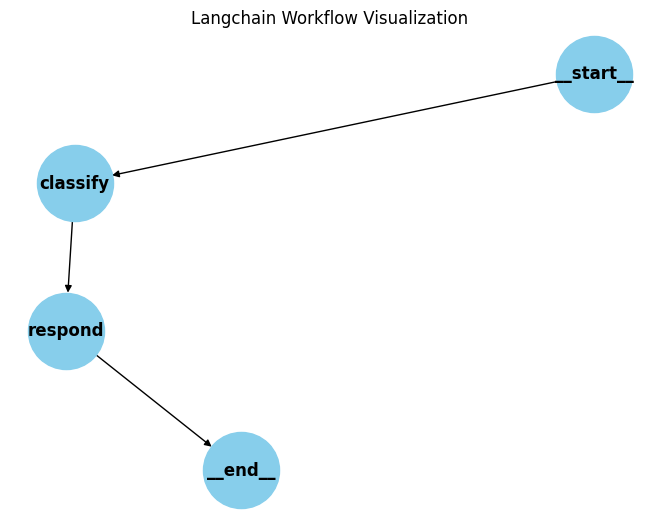

In [7]:
import networkx as nx
import matplotlib.pyplot as plt
from langgraph.graph import StateGraph

builder = StateGraph(GraphState)
builder.add_node("classify", classify)
builder.add_node("respond", respond)
builder.set_entry_point("classify")
builder.add_edge("classify", "respond")
builder.set_finish_point("respond")
app = builder.compile()

def visualize_workflow(builder):
    G = nx.DiGraph()

    for node in builder.nodes:
        G.add_node(node)
    for edge in builder.edges:
        G.add_edge(edge[0], edge[1])

    pos = nx.spring_layout(G)
    nx.draw(G, pos, with_labels=True, node_size=3000,
            node_color="skyblue", font_size=12, font_weight="bold", arrows=True)

    plt.title("Langchain Workflow Visualization")
    plt.show()

visualize_workflow(builder)

In [8]:
while True:
    user_input = input("You: ")
    if user_input.strip().lower() in ['exit', 'quit']:
        print("Bot: Goodbye!")
        break

    state = {"question": user_input}
    result = app.invoke(state)
    print("Bot:", result["response"])

Bot: Hello! How can I help you today?
Bot: I'm glad to help answer your questions to the best of my ability! Let me see if I can assist you with your query. If I don't know the answer, I'll do my best to find one for you. How can I help you today?
Bot: I'm glad to help answer your questions to the best of my ability! Let me see if I can assist you with your query. If I don't know the answer, I'll do my best to find one for you. How can I help you today?
Bot: Goodbye!
Bot: Goodbye!
